# Mushroom Decision Tree (Reduced Features) — Student Exercise
## Your Name:
## Date:
### In Blackboard you will submit your Github URL after saving your notebook to your class repository, AND a PDF of this notebook (in Colab, File . . . Print . . . PDF)
This activity uses a simplified version of the Mushroom dataset to create a decision tree.

## Goals
- Build a decision tree classifier
- Interpret a confusion matrix and accuracy
- Explain what the root and first-level nodes mean
- Translate tree splits into plain English


## 1️⃣ Setup

In [4]:

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


## 2️⃣ Load the Mushroom dataset (code is completed for you)
**Target:** `class`
- `e` = edible which becomes 0 or not poisonous
- `p` = poisonous which becomes 1

In [5]:
#note feature names, we will reduce these
mush = fetch_openml('mushroom', version=1, as_frame=True)
df = mush.frame.copy()
# rename the column
df = df.rename(columns={"bruises%3F": "bruises"})
df.head()


,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,x,s,n,t,p,f,c,n,k,e,...,w,w,p,w,o,p,k,s,u,p
1,x,s,y,t,a,f,c,b,k,e,...,w,w,p,w,o,p,n,n,g,e
2,b,s,w,t,l,f,c,b,n,e,...,w,w,p,w,o,p,n,n,m,e
3,x,y,w,t,p,f,c,n,n,e,...,w,w,p,w,o,p,k,s,u,p
4,x,s,g,f,n,f,w,b,k,t,...,w,w,p,w,o,e,n,a,g,e


## 3️⃣ Use a reduced feature set (code is completed for you)
These features are highly predictive and keep the tree readable. Note the class is mapped to 0 (edible) and 1 (poisonous).

In [6]:

features = ['odor', 'spore-print-color', 'gill-size', 'gill-color', 'bruises']

X = df[features]
y = df['class'].map({'e':0, 'p':1})

X.head(), y.value_counts()


(  odor spore-print-color gill-size gill-color bruises
 0    p                 k         n          k       t
 1    a                 n         b          k       t
 2    l                 n         b          n       t
 3    p                 k         n          n       t
 4    n                 n         b          k       f,
 class
 0    4208
 1    3916
 Name: count, dtype: int64)

## 4️⃣ One‑hot encode the categorical features (Add Code)
Each category becomes a YES/NO column.

In [7]:
import pandas as pd
X = pd.get_dummies(df[features])
X.head()

,odor_a,odor_c,odor_f,odor_l,odor_m,odor_n,odor_p,odor_s,odor_y,spore-print-color_b,...,gill-color_k,gill-color_n,gill-color_o,gill-color_p,gill-color_r,gill-color_u,gill-color_w,gill-color_y,bruises_f,bruises_t
0,False,False,False,False,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
1,True,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,True
2,False,False,False,True,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,True,False,False,False,...,False,True,False,False,False,False,False,False,False,True
4,False,False,False,False,False,True,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False


## 5️⃣ Train/test split (Add Code)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## 6️⃣ Train a small decision tree (Add Code)

In [10]:
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)



DecisionTreeClassifier(max_depth=3, random_state=42)

## 7️⃣ Evaluate the model (Add Code)

In [11]:
y_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Accuracy: 0.9581538461538461

Confusion Matrix:
[[843   0]
 [ 68 714]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       843
           1       1.00      0.91      0.95       782

    accuracy                           0.96      1625
   macro avg       0.96      0.96      0.96      1625
weighted avg       0.96      0.96      0.96      1625



## 8️⃣ Visualize the decision tree (Add Code)

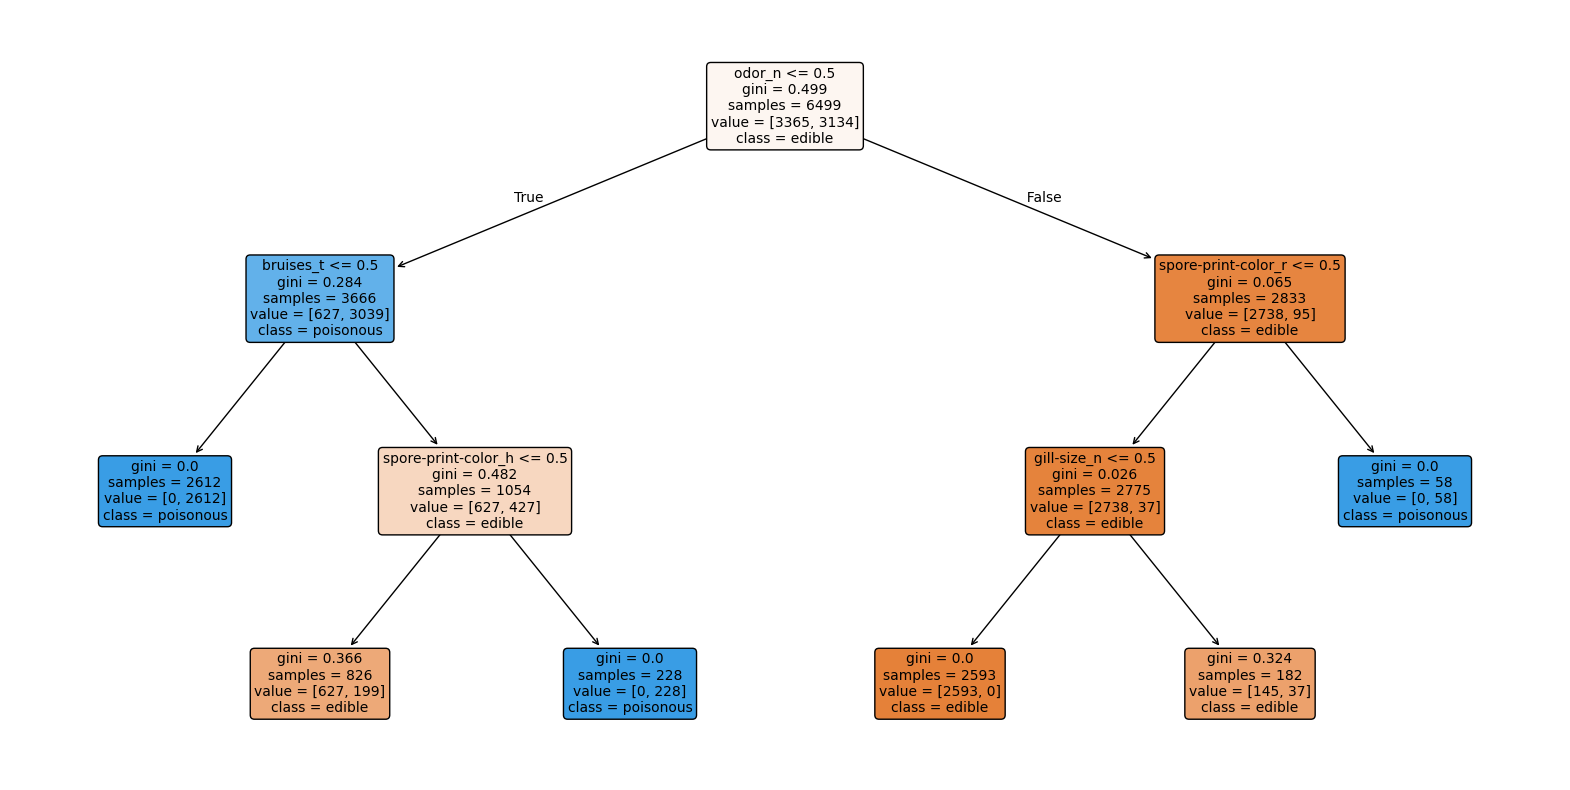

In [12]:
plt.figure(figsize=(20, 10))
plot_tree(
    dt,
    feature_names=X.columns,
    class_names=['edible', 'poisonous'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()


## 9️⃣ Print IF–THEN rules (Add Code)

In [13]:
rules = export_text(dt, feature_names=list(X.columns))
print(rules)


|--- odor_n <= 0.50
|   |--- bruises_t <= 0.50
|   |   |--- class: 1
|   |--- bruises_t >  0.50
|   |   |--- spore-print-color_h <= 0.50
|   |   |   |--- class: 0
|   |   |--- spore-print-color_h >  0.50
|   |   |   |--- class: 1
|--- odor_n >  0.50
|   |--- spore-print-color_r <= 0.50
|   |   |--- gill-size_n <= 0.50
|   |   |   |--- class: 0
|   |   |--- gill-size_n >  0.50
|   |   |   |--- class: 0
|   |--- spore-print-color_r >  0.50
|   |   |--- class: 1



---
# QUESTIONS TO ANSWER (provide answers in markdown)
### Confusion Matrix & Accuracy
1. What was the model accuracy?
2. How many poisonous mushrooms were correctly classified?
3. How many poisonous mushrooms were incorrectly predicted as edible?
4. Why is misclassifying a poisonous mushroom more serious than misclassifying an edible one?

### Understanding the Tree
5. What feature appears at the **root node**?
6. What question is the root node asking in plain English?
7. Describe what the **left branch** and **right branch** mean.

### First Level Nodes
8. Look at the two nodes directly below the root.
   - What feature does each split on?
   - What question is each node asking?
   - What does following the left vs right branch mean?

### Interpretation
9. Choose ONE full path from the root to a leaf and translate it into plain English.
10. Based on the tree, what feature seems most important for predicting if a mushroom is poisonous?

### Exploration
11. Change `max_depth` to 2. What changed?
12. Change `max_depth` to 5. What changed?


---
# QUESTIONS TO ANSWER (provide answers in markdown)
### Confusion Matrix & Accuracy
1. What was the model accuracy? 0.958
2. How many poisonous mushrooms were correctly classified? 714
3. How many poisonous mushrooms were incorrectly predicted as edible? 68
4. Why is misclassifying a poisonous mushroom more serious than misclassifying an edible one? Eating a poisonous mushroom can kill you, avoiding an edible one is harmless.

### Understanding the Tree
5. What feature appears at the **root node**? Odor
6. What question is the root node asking in plain English? “Does the mushroom have odor ‘none’?”
7. Describe what the **left branch** and **right branch** mean. Left branch: odor is not “none.”
Right branch: odor is “none.”

### First Level Nodes
8. Look at the two nodes directly below the root.
   - What feature does each split on?
   - What question is each node asking?
   - What does following the left vs right branch mean? Left child split: bruises

Question: “Does it bruise?”

Left: no bruises

Right: bruises

Right child split: spore‑print‑color_r

Question: “Is the spore print red?”

Left: not red

Right: red

### Interpretation
9. Choose ONE full path from the root to a leaf and translate it into plain English. If odor is “none” AND spore‑print‑color is not red → edible.
10. Based on the tree, what feature seems most important for predicting if a mushroom is poisonous? Odor

### Exploration
11. Change `max_depth` to 2. What changed? Tree becomes simple, fewer splits, slightly less accurate.
12. Change `max_depth` to 5. What changed? Tree becomes larger, more detailed, risk of overfitting increases.
